In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


In [18]:
df = pd.read_csv(r"C:\Users\shrad\Downloads\Cleaned_dataset_energy_poverty (2).csv")
df["energy_score"] = (
    (df["Electricity"] == 0) * 3 +
    (df["hrs_elect"] < 8) * 2 +
    (df["cfuel"] == 1) * 2 +
    (df["avl_lpg"] == 0) * 1 +
    (df["ipollut"] == 1) * 1
)
df["Energy_Poverty"] = (df["energy_score"] >= 3).astype(int)

# Drop irrelevant/redundant columns
if "hh" in df.columns:
    df = df.drop("hh", axis=1)

X = df.drop(["Energy_Poverty", "energy_score", "Electricity", "hrs_elect", "cfuel", "avl_lpg", "ipollut"], axis=1)
y = df["Energy_Poverty"]

# 3. Scaling features (Crucial for distance-based models like SVM and Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "SVM (Prob)": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=== 5-Fold Cross-Validation Accuracy ===")
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Save Cross Validation results
cv_df = pd.DataFrame(cv_results).T
cv_df.columns = [f"Fold {i+1}" for i in range(5)]
cv_df["Mean Accuracy"] = cv_df.mean(axis=1)
cv_df["Std Dev"] = cv_df.std(axis=1)
cv_df.to_csv("cv_results.csv")





=== 5-Fold Cross-Validation Accuracy ===
Logistic Regression: 0.6473 (+/- 0.1054)
Decision Tree: 0.6111 (+/- 0.0803)
Random Forest: 0.6753 (+/- 0.0487)
SVM (Prob): 0.6814 (+/- 0.0744)
Gradient Boosting: 0.6393 (+/- 0.0274)



=== Test Set ROC AUC ===
Logistic Regression AUC: 0.7275
Decision Tree AUC: 0.6439
Random Forest AUC: 0.7682
SVM (Prob) AUC: 0.7534
Gradient Boosting AUC: 0.7464


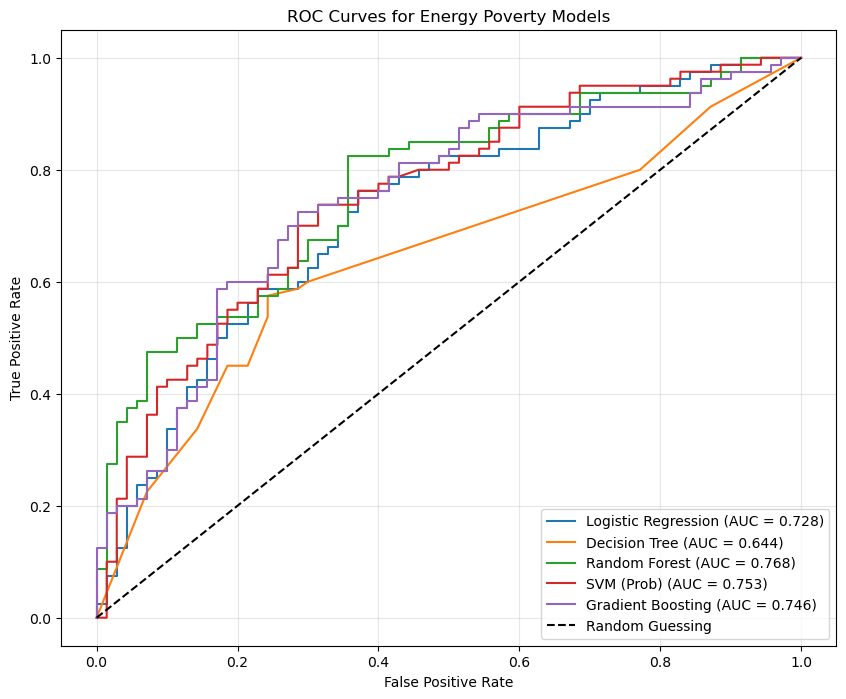

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

plt.figure(figsize=(10, 8))
print("\n=== Test Set ROC AUC ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    # Get probabilities for ROC curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
        
    auc = roc_auc_score(y_test, y_prob)
    print(f"{name} AUC: {auc:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Energy Poverty Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig("roc_curves.png", bbox_inches='tight')